In [ ]:
import os
import pickle
import sys
sys.path.append("/data1/morrisq/divyak/projects/metient/notebooks/lineage_tracing")
import lineage_tracing_utilities as lt
import torch
import numpy as np
import gzip
import networkx as nx
import pandas as pd
from ete3 import Tree
import gzip
import numpy.core.numeric
# alias old module path → new one
sys.modules['numpy._core.numeric'] = numpy.core.numeric
import metient.util.vertex_labeling_util as vutil
from metient.util.globals import *
import metient as met

import matplotlib.pyplot as plt
output_dir = "/data1/morrisq/divyak/projects/metient/notebooks/outputs"

# Change this to where reproducibility data is stored (Download here: https://github.com/divyakoyy/metient_reproducibility)
DATA_DIR = "/data1/morrisq/divyak/data/metient_reproducibility/lung_lineage_tracing"
metient_results_dir = os.path.join(DATA_DIR, "metient_outputs")

CLONE = 15


### Load solutions for clone 15

In [2]:
mig_graphs = []
pars_metrics_data = []
three_solutions = []
_, weighted_scaled_tissue_trans, pars_metrics, mig_graphs = lt.extract_info(metient_results_dir, CLONE)

for x,metric in enumerate(pars_metrics):
    three_solutions = [0, len(pars_metrics)//2, len(pars_metrics)-1]
    name = f"Solution {x+1}" if x in three_solutions else f"All other solutions"
    pars_metrics_data.append([metric[0], metric[1], metric[2],name,])

14 solutions


/home/koyyald/miniforge3/envs/met/lib/python3.9/site-packages/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]


In [3]:
def normalize_mig_graph(mig_graph):
    # Get total sum of all elements
    total_sum = mig_graph.sum()
    # If sum is 0, avoid division by zero
    total_sum = total_sum if total_sum != 0 else torch.tensor(1.0)
    # Divide each element by total sum to make everything sum to 1
    normed_tissue_trans = mig_graph / total_sum
    # Zero out small values and those below threshold
    normed_tissue_trans[normed_tissue_trans < 0.01] = 0
    return normed_tissue_trans

print(lt.TISSUE_ORDER)
for x in three_solutions:
    print(x)
    normed = normalize_mig_graph(mig_graphs[x])
    print(f"Solution {x+1}")
    print(normed)
    print(pars_metrics_data[x])

['LL', 'RE', 'RW', 'M1', 'M2', 'Liv']
0
Solution 1
tensor([[0.00, 0.00, 0.00, 0.04, 0.04, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.10, 0.10, 0.07, 0.00, 0.43, 0.06],
        [0.00, 0.00, 0.02, 0.10, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]])
[124, 14, 3, 'Solution 1']
7
Solution 8
tensor([[0.00, 0.07, 0.05, 0.42, 0.35, 0.05],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.02, 0.00, 0.02, 0.00],
        [0.00, 0.00, 0.00, 0.04, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]])
[196, 9, 3, 'Solution 8']
13
Solution 14
tensor([[0.00, 0.06, 0.05, 0.42, 0.42, 0.04],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00]])
[226, 5, 1, 'Solution 14']


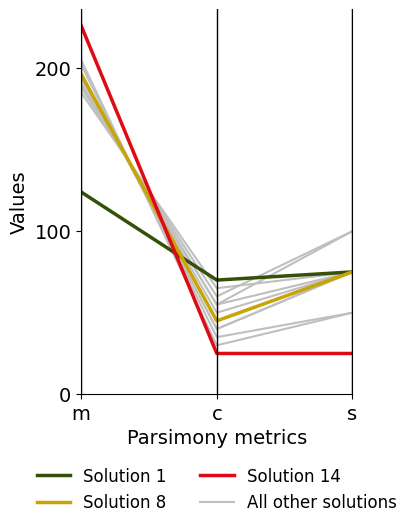

In [4]:
from pandas.plotting import parallel_coordinates

priority_solns = [f'Solution {x+1}' for x in three_solutions]
pars_metrics_df = pd.DataFrame(pars_metrics_data, columns=["Migration #", "Comigration #", "Seeding site #", "Clone", ])
pars_metrics_df["Comigration #"] = pars_metrics_df["Comigration #"]*5

pars_metrics_df["Seeding site #"] = pars_metrics_df["Seeding site #"]*25
non_priority_solns = pars_metrics_df[~pars_metrics_df['Clone'].isin(priority_solns)]
priority_solns_df = pars_metrics_df[pars_metrics_df['Clone'].isin(priority_solns)]

# Reorder the DataFrame so that priority clones are last
pars_metrics_df_ordered = pd.concat([non_priority_solns, priority_solns_df])


colors = ["#bfbfbf", "#335109","#c9a406","#e00a14",]

plt.figure(figsize=(3.5,5))
ax = parallel_coordinates(pars_metrics_df_ordered, 'Clone', color=colors, linewidth=1.8)
ax.spines['left'].set_color('black')  # Set the color of the y-axis spine to black
ax.spines['right'].set_color('black')  # Set the color of the y-axis spine to black
ax.spines['bottom'].set_color('black')  # Set the color of the y-axis spine to black

linewidth_mapping = {f'Solution {x+1}': 2.5 for x in three_solutions}
linewidth_mapping['All other solutions'] = 1.5

# Iterate over the lines in the plot and update their linewidths based on the hue
for line, label in zip(ax.get_lines(), pars_metrics_df_ordered['Clone']):
    line.set_linewidth(linewidth_mapping[label])

ax.tick_params(axis='y', colors='black')  # Set the color of y-axis ticks and labels to black

plt.xlabel("Parsimony metrics",fontsize=14)
plt.ylabel("Values",fontsize=14)
plt.grid(False)
# Remove the right and top spines (axes)
ax.spines['top'].set_visible(False)

plt.xticks([0,1,2], ["m","c","s"], fontsize=14)
plt.yticks([0,100, 200,], fontsize=14)
handles, labels = plt.gca().get_legend_handles_labels()
desired_order = priority_solns + ['All other solutions']
ordered_handles = [handles[labels.index(label)] for label in desired_order]
ordered_labels = [labels[labels.index(label)] for label in desired_order]
plt.legend(ordered_handles, ordered_labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False, ncol=2, fontsize=12)

plt.savefig(os.path.join(output_dir, f"parallel_coordinates_subset_clones.svg"), dpi=500, bbox_inches='tight',pad_inches=0.1)
plt.show()
plt.close()

In [5]:
# Convert networkx tree to ete3 tree
def networkx_to_ete(tree, root):
    # Recursively build the tree
    ete_tree = Tree(name=str(root))
    for child in tree.successors(root):
        ete_tree.add_child(networkx_to_ete(tree, child))
    return ete_tree


def nodes_to_white(tree, reference_V):
    nodes = []
    for node in tree.nodes():
        if np.argmax(V[:, node]) != np.argmax(reference_V[:, node]):
            nodes.append(node)
    return nodes


with gzip.open(os.path.join(metient_results_dir,f"{CLONE}_LL.pkl.gz") ,"rb") as f:
    pckl = pickle.load(f)
    
num_solutions = len(pckl[OUT_LABElING_KEY])
print(f"{num_solutions} solutions")
ordered_sites = pckl[OUT_SITES_KEY]
A = met.adjacency_matrix_from_parents(pckl[OUT_PARENTS_KEY][0])

root_idx = vutil.get_root_index(A)
# This is the solution to get the diff of labels for
reference_idx = num_solutions - 1
reference_V = pckl[OUT_LABElING_KEY][reference_idx]

for tree_idx in three_solutions:
    print("Solution",tree_idx)
    V = pckl[OUT_LABElING_KEY][tree_idx]
    
    tree = nx.DiGraph()
    edges = zip(A._indices()[0].tolist(), A._indices()[1].tolist())
    tree.add_edges_from(edges)
    num_nodes = V.shape[1]
    tree.add_nodes_from(range(num_nodes))

    # If this is not the first, best solution, we want to label all nodes that 
    # have the same label as the best migration history "white"
    diff_label_from_ref_soln_nodes = nodes_to_white(tree, reference_V) if tree_idx != reference_idx else range(num_nodes)
    for node in tree.nodes():

        tissue = ordered_sites[np.argmax(V[:, node])]
        if node not in diff_label_from_ref_soln_nodes:
            tissue = "W"
        tree.nodes[node]['tissue'] = tissue
    
    ete_tree = networkx_to_ete(tree, root_idx)
    # Add NHX-style metadata (assuming one type of metadata here, for simplicity)
    for node in ete_tree.traverse():
        if int(node.name) in tree.nodes:
            label = tree.nodes[int(node.name)]['tissue']
            node.add_features(NHX=label)

    # Export to Newick format
    newick_str = ete_tree.write(features=["NHX"])
    with open(os.path.join(output_dir, f'{CLONE}_solution{tree_idx}_tree_with_nhx_W.newick'), 'w') as f:
        f.write(newick_str)
        f.flush()


14 solutions
Solution 0
Solution 7
Solution 13


/home/koyyald/miniforge3/envs/met/lib/python3.9/site-packages/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]
